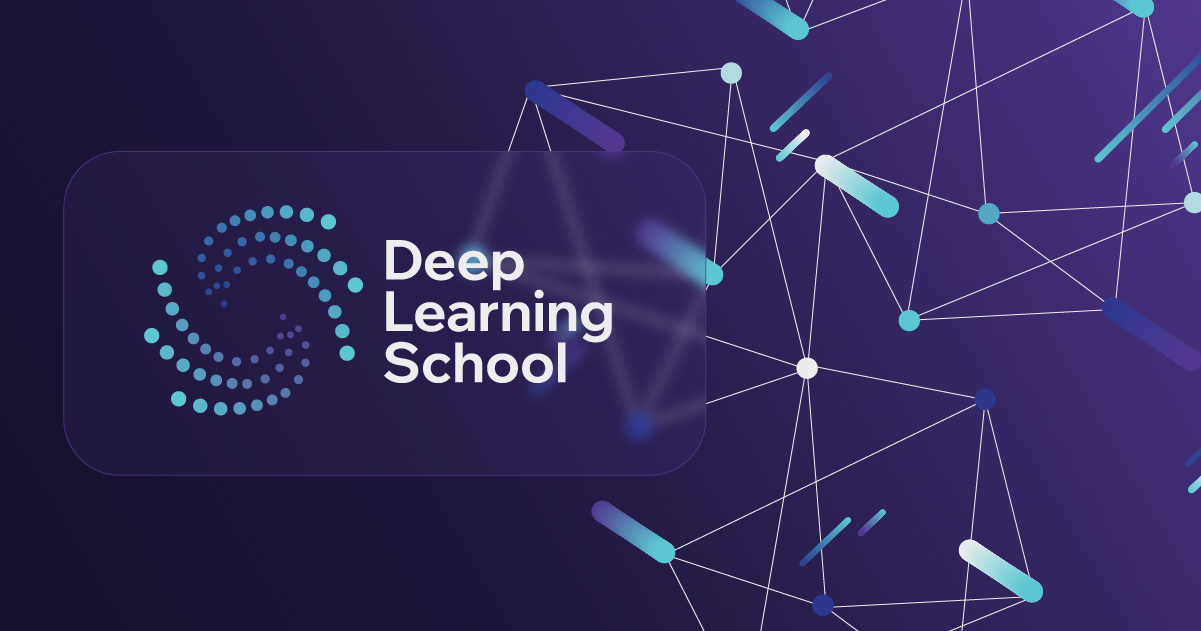

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

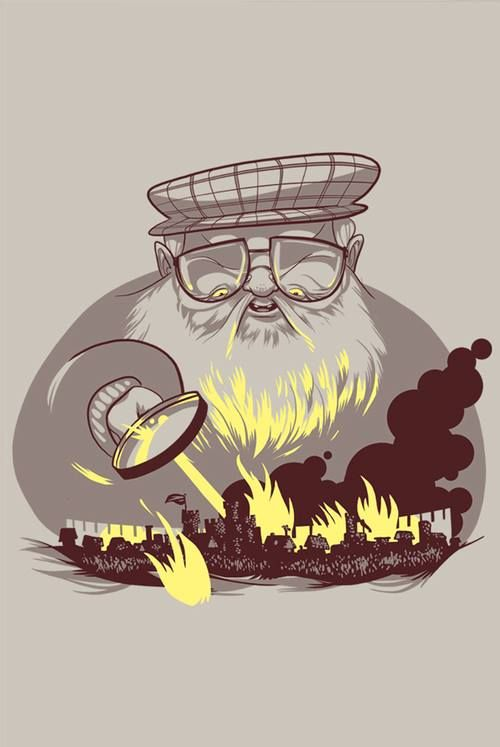

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [ ]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 51.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 46.0MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [ ]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')
test = pd.read_csv('game_of_thrones_test.csv', index_col='S.No')

In [ ]:
data.head(10)

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1
6,Tommen Baratheon,NaN,1,NaN,NaN,Cersei Lannister,Robert Baratheon,Myrcella Baratheon,NaN,NaN,...,1.0,1.0,1.0,NaN,0,0,NaN,5,1.000000,1
7,Valarr Targaryen,Hand of the King,1,Valyrian,183.0,NaN,NaN,NaN,House Targaryen,Kiera of Tyrosh,...,NaN,NaN,NaN,1.0,1,1,26.0,0,0.431438,0
8,Viserys I Targaryen,NaN,1,NaN,NaN,Alyssa Targaryen,Baelon Targaryen,Rhaenyra Targaryen,NaN,NaN,...,1.0,1.0,1.0,NaN,0,0,NaN,5,0.678930,0
9,Wilbert,Ser,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.006689,0


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 1558 to 1946
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              389 non-null    object 
 1   title             221 non-null    object 
 2   male              389 non-null    int64  
 3   culture           189 non-null    object 
 4   dateOfBirth       154 non-null    float64
 5   mother            3 non-null      object 
 6   father            4 non-null      object 
 7   heir              2 non-null      object 
 8   house             343 non-null    object 
 9   spouse            76 non-null     object 
 10  book1             389 non-null    int64  
 11  book2             389 non-null    int64  
 12  book3             389 non-null    int64  
 13  book4             389 non-null    int64  
 14  book5             389 non-null    int64  
 15  isAliveMother     3 non-null      float64
 16  isAliveFather     4 non-null      float64
 17

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              1557 non-null   object 
 1   title             717 non-null    object 
 2   male              1557 non-null   int64  
 3   culture           488 non-null    object 
 4   dateOfBirth       279 non-null    float64
 5   mother            18 non-null     object 
 6   father            22 non-null     object 
 7   heir              21 non-null     object 
 8   house             1176 non-null   object 
 9   spouse            200 non-null    object 
 10  book1             1557 non-null   int64  
 11  book2             1557 non-null   int64  
 12  book3             1557 non-null   int64  
 13  book4             1557 non-null   int64  
 14  book5             1557 non-null   int64  
 15  isAliveMother     18 non-null     float64
 16  isAliveFather     22 non-null     float64
 17  

Посмотрите, какие типы данных представлены в нашем датасете

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [ ]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [ ]:
data.describe(include = ['int64', 'float64']).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

In [ ]:
missing_values = data.isnull().sum()
missing_values[missing_values>0]

,0
title,840
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357
isAliveMother,1539
isAliveFather,1535


В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

<Axes: >

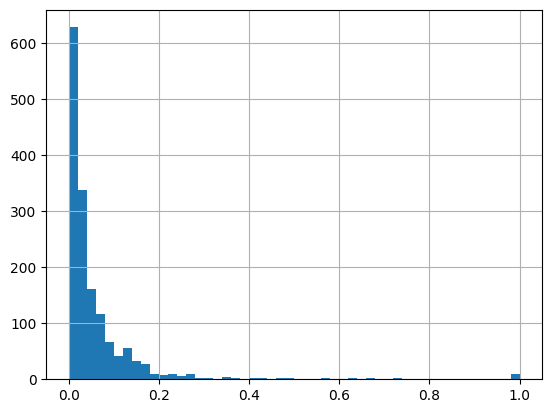

In [ ]:
data['popularity'].hist(bins=50)

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


In [ ]:
M = 100

data['popularity'] = np.log10(data['popularity'] * M + 1)

data['popularity'].head()

,popularity
S.No,
1,1.789123
2,1.957282
3,1.443355
4,1.287682
5,0.728177


<Axes: >

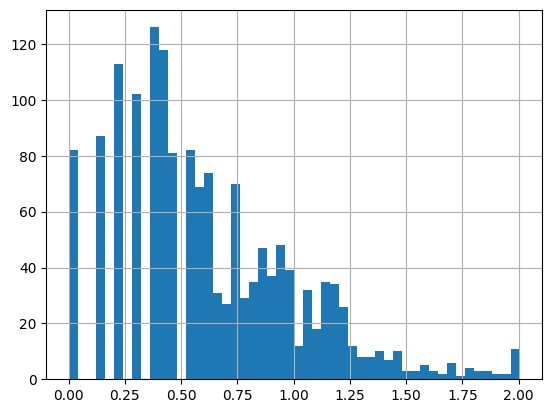

In [ ]:
data['popularity'].hist(bins=50)

В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

<Axes: >

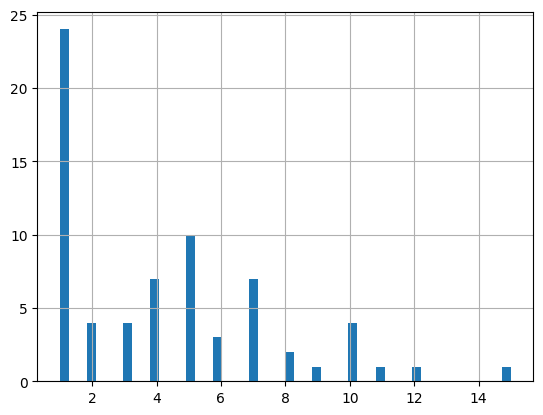

In [ ]:
data.loc[(data.numDeadRelations > 0)]['numDeadRelations'].hist(bins=50)

In [ ]:
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)

In [ ]:
data['boolDeadRelations'].value_counts()

,count
boolDeadRelations,
0,1488
1,69


Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [ ]:
data['age_value'] = data['age'].fillna(0)
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

data.drop(columns=['age'], inplace=True)
data[['age_no_data', 'age_value']].head()

,age_no_data,age_value
S.No,,
1,1,0.0
2,0,97.0
3,1,0.0
4,0,23.0
5,0,29.0


Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [ ]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [ ]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [ ]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [ ]:
# По аналогии с примером выше инвертируйте словарь cultures_grouped
cultures_grouped_inverted = {}
for k, v_list in cultures_grouped.items():
  for v in v_list:
    cultures_grouped_inverted[v] = k

cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

In [ ]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [ ]:
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')
data.drop(columns=['culture'], inplace=True)

In [ ]:
data.head(10)

,name,title,male,dateOfBirth,mother,father,heir,house,spouse,book1,...,isAliveSpouse,isMarried,isNoble,numDeadRelations,popularity,isAlive,boolDeadRelations,age_value,age_no_data,culture_grouped
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,0,...,NaN,0,0,11,1.789123,0,1,0.0,1,culture_no_data
2,Walder Frey,Lord of the Crossing,1,208.0,NaN,NaN,NaN,House Frey,Perra Royce,1,...,1.0,1,1,1,1.957282,1,1,97.0,0,the Isles and Rivers
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,House Swyft,NaN,0,...,NaN,0,1,0,1.443355,1,0,0.0,1,culture_no_data
4,Aemma Arryn,Queen,0,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,0,...,0.0,1,1,0,1.287682,0,0,23.0,0,culture_no_data
5,Sylva Santagar,Greenstone,0,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,0,...,1.0,1,1,0,0.728177,1,0,29.0,0,Dorne
6,Tommen Baratheon,NaN,1,NaN,Cersei Lannister,Robert Baratheon,Myrcella Baratheon,NaN,NaN,0,...,NaN,0,0,5,2.004321,1,1,0.0,1,culture_no_data
7,Valarr Targaryen,Hand of the King,1,183.0,NaN,NaN,NaN,House Targaryen,Kiera of Tyrosh,0,...,1.0,1,1,0,1.644870,0,0,26.0,0,Old Nations
8,Viserys I Targaryen,NaN,1,NaN,Alyssa Targaryen,Baelon Targaryen,Rhaenyra Targaryen,NaN,NaN,0,...,NaN,0,0,5,1.838175,0,1,0.0,1,culture_no_data
9,Wilbert,Ser,1,NaN,NaN,NaN,NaN,NaN,NaN,0,...,NaN,0,1,0,0.222429,0,0,0.0,1,culture_no_data


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1557 non-null   object 
 1   title              717 non-null    object 
 2   male               1557 non-null   int64  
 3   dateOfBirth        279 non-null    float64
 4   mother             18 non-null     object 
 5   father             22 non-null     object 
 6   heir               21 non-null     object 
 7   house              1176 non-null   object 
 8   spouse             200 non-null    object 
 9   book1              1557 non-null   int64  
 10  book2              1557 non-null   int64  
 11  book3              1557 non-null   int64  
 12  book4              1557 non-null   int64  
 13  book5              1557 non-null   int64  
 14  isAliveMother      18 non-null     float64
 15  isAliveFather      22 non-null     float64
 16  isAliveHeir        21 non-nul

In [ ]:
data.drop(columns=['mother', 'father', 'heir', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'], inplace=True)

In [ ]:
data['title'] = data['title'].fillna('Unknown')
data['title'].value_counts()

,count
title,
Unknown,840
Ser,306
Maester,29
Archmaester,21
Lord,19
...,...
Lord of Hellholt,1
Red Flower Vale,1
Lord of Harrenhal,1


In [ ]:
data['dateOfBirth'] = data['dateOfBirth'].fillna(0)

In [ ]:
data['house_no_data'] = [1 if pd.isna(x) else 0 for x in data['house']]

data['house'] = data['house'].fillna('no_house')
data[['house', 'house_no_data']].head()

,house,house_no_data
S.No,,
1,no_house,1
2,House Frey,0
3,House Swyft,0
4,House Arryn,0
5,House Santagar,0


In [ ]:
data['has_spouse'] = [0 if pd.isna(x) else 1 for x in data['spouse']]
data.drop(columns='spouse', inplace=True)
data['has_spouse'].head(10)

,has_spouse
S.No,
1,0
2,1
3,0
4,1
5,1
6,0
7,1
8,0
9,0


In [ ]:
data['has_spouse'].value_counts()

,count
has_spouse,
0,1357
1,200


Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [ ]:
# Количество уникальнх значений в каждом столбце
data.nunique()

,0
name,1557
title,196
male,2
dateOfBirth,106
house,316
book1,2
book2,2
book3,2
book4,2
book5,2


In [ ]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
data.describe(include = ['int64', 'float64', 'object']).T[['count', 'min', 'max']].assign(N_unique_values = data.nunique())

,count,min,max,N_unique_values
name,1557,NaN,NaN,1557
title,1557,NaN,NaN,196
male,1557.0,0.0,1.0,2
dateOfBirth,1557.0,-25.0,299.0,106
house,1557,NaN,NaN,316
book1,1557.0,0.0,1.0,2
book2,1557.0,0.0,1.0,2
book3,1557.0,0.0,1.0,2
book4,1557.0,0.0,1.0,2
book5,1557.0,0.0,1.0,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [ ]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:

# data.groupby('НАЗВАНИЕ ПРИЗНАКА', dropna = False)['isAlive'].mean()
# pd.pivot_table(data = data, values = 'isAlive', index = 'НАЗВАНИЕ ПРИЗНАКА', aggfunc=['mean', 'count'], dropna=False)

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

culture_encoded = encoder.fit_transform(data[['culture_grouped']])
clean_columns = encoder.categories_[0]
culture_df = pd.DataFrame(culture_encoded,
                          columns=clean_columns,
                          index=data.index)
data = pd.concat([data, culture_df], axis=1)
data.drop(columns=['culture_grouped'], inplace=True)

In [ ]:
data.head(10)

,name,title,male,dateOfBirth,house,book1,book2,book3,book4,book5,...,Old Nations,Other Nations,culture_no_data,the Iron Islands,the Isles and Rivers,the Mountain and the Vale,the North,the Reach,the Rock,the Stormlands
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,Unknown,1,0.0,no_house,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Walder Frey,Lord of the Crossing,1,208.0,House Frey,1,1,1,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,Addison Hill,Ser,1,0.0,House Swyft,0,0,0,1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aemma Arryn,Queen,0,82.0,House Arryn,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Sylva Santagar,Greenstone,0,276.0,House Santagar,0,0,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,Tommen Baratheon,Unknown,1,0.0,no_house,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,Valarr Targaryen,Hand of the King,1,183.0,House Targaryen,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,Viserys I Targaryen,Unknown,1,0.0,no_house,0,0,0,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,Wilbert,Ser,1,0.0,no_house,0,0,1,0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
data.loc[5]

,5
name,Sylva Santagar
title,Greenstone
male,0
dateOfBirth,276.0
house,House Santagar
book1,0
book2,0
book3,0
book4,1
book5,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       1557 non-null   object 
 1   title                      1557 non-null   object 
 2   male                       1557 non-null   int64  
 3   dateOfBirth                1557 non-null   float64
 4   house                      1557 non-null   object 
 5   book1                      1557 non-null   int64  
 6   book2                      1557 non-null   int64  
 7   book3                      1557 non-null   int64  
 8   book4                      1557 non-null   int64  
 9   book5                      1557 non-null   int64  
 10  isMarried                  1557 non-null   int64  
 11  isNoble                    1557 non-null   int64  
 12  numDeadRelations           1557 non-null   int64  
 13  popularity                 1557 non-null   float64
 1

In [ ]:
data['house'].value_counts().nlargest(12)

,count
house,
no_house,381
House Frey,89
Night's Watch,88
House Stark,56
House Targaryen,40
House Lannister,36
House Tyrell,33
House Greyjoy,30
House Osgrey,20


In [ ]:
top_houses = data['house'].value_counts().nlargest(12).index

data['house_grouped'] = data['house'].apply(lambda x: x if x in top_houses else 'Other')

In [ ]:
data['house_grouped'].value_counts()

,count
house_grouped,
Other,745
no_house,381
House Frey,89
Night's Watch,88
House Stark,56
House Targaryen,40
House Lannister,36
House Tyrell,33
House Greyjoy,30


In [ ]:
encoder_h = OneHotEncoder(sparse_output=False)
house_encoded = encoder_h.fit_transform(data[['house_grouped']])
clean_columns_h = encoder_h.categories_[0]
house_df = pd.DataFrame(
    house_encoded,
    columns=clean_columns_h,
    index=data.index
)

data = pd.concat([data, house_df], axis=1)
data.drop(columns=['house', 'house_grouped'], inplace=True)

In [ ]:
data.head()

,name,title,male,dateOfBirth,book1,book2,book3,book4,book5,isMarried,...,House Greyjoy,House Hightower,House Lannister,House Osgrey,House Stark,House Targaryen,House Tyrell,Night's Watch,Other,no_house
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,Unknown,1,0.0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,Walder Frey,Lord of the Crossing,1,208.0,1,1,1,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Addison Hill,Ser,1,0.0,0,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,Aemma Arryn,Queen,0,82.0,0,0,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,Sylva Santagar,Greenstone,0,276.0,0,0,0,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 44 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   name                       1557 non-null   object 
 1   title                      1557 non-null   object 
 2   male                       1557 non-null   int64  
 3   dateOfBirth                1557 non-null   float64
 4   book1                      1557 non-null   int64  
 5   book2                      1557 non-null   int64  
 6   book3                      1557 non-null   int64  
 7   book4                      1557 non-null   int64  
 8   book5                      1557 non-null   int64  
 9   isMarried                  1557 non-null   int64  
 10  isNoble                    1557 non-null   int64  
 11  numDeadRelations           1557 non-null   int64  
 12  popularity                 1557 non-null   float64
 13  isAlive                    1557 non-null   int64  
 1

In [ ]:
data.drop(columns=['name', 'title'], inplace=True)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 42 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   male                       1557 non-null   int64  
 1   dateOfBirth                1557 non-null   float64
 2   book1                      1557 non-null   int64  
 3   book2                      1557 non-null   int64  
 4   book3                      1557 non-null   int64  
 5   book4                      1557 non-null   int64  
 6   book5                      1557 non-null   int64  
 7   isMarried                  1557 non-null   int64  
 8   isNoble                    1557 non-null   int64  
 9   numDeadRelations           1557 non-null   int64  
 10  popularity                 1557 non-null   float64
 11  isAlive                    1557 non-null   int64  
 12  boolDeadRelations          1557 non-null   int64  
 13  age_value                  1557 non-null   float64
 1

In [ ]:
data.drop(columns=['has_spouse', 'house_no_data', 'dateOfBirth'], inplace=True)

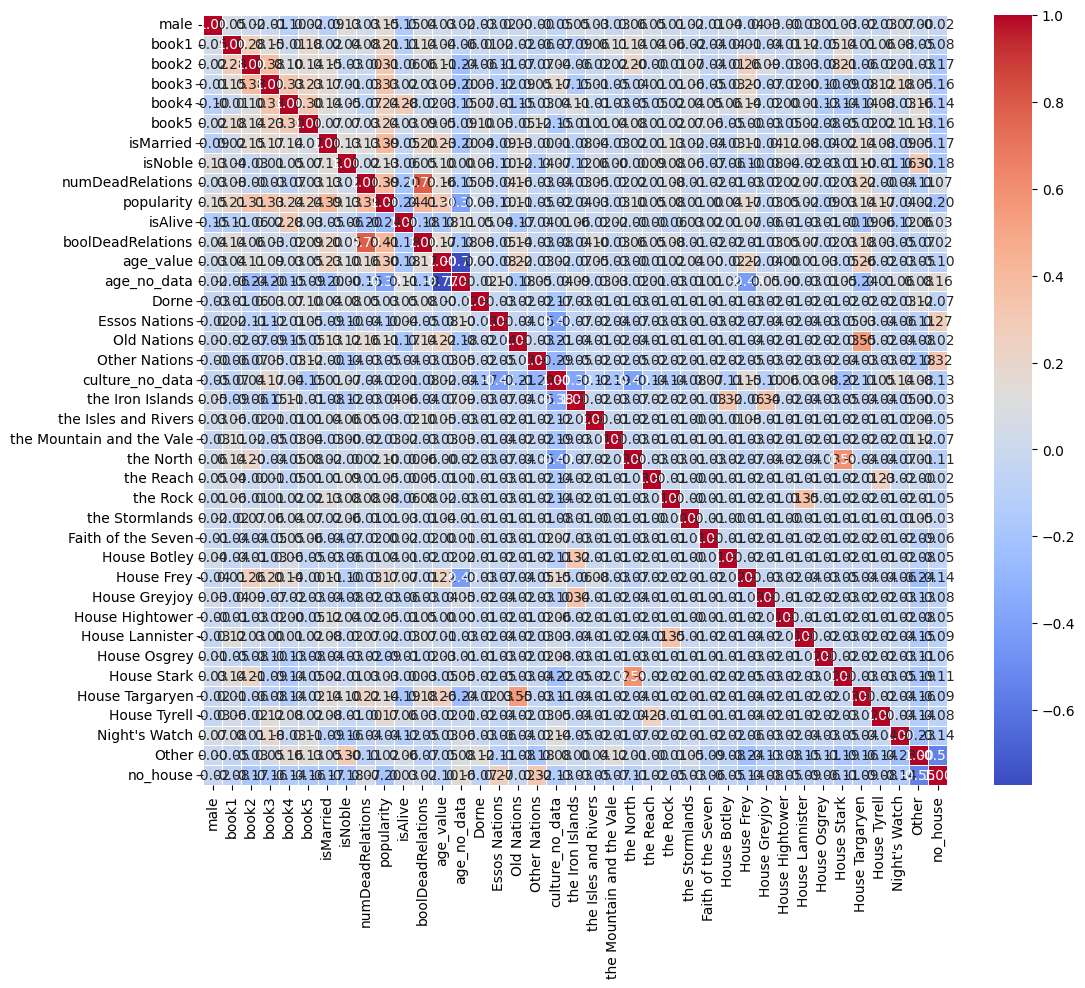

In [ ]:
corr_matrix = data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.show()

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

In [ ]:
correlations = data.corr()['isAlive'].sort_values(ascending=False)
print(correlations)

isAlive                      1.000000
book4                        0.284014
age_no_data                  0.113629
House Frey                   0.071415
the Iron Islands             0.064933
Other                        0.062154
House Tyrell                 0.057036
Dorne                        0.048977
Essos Nations                0.037287
no_house                     0.033892
book5                        0.032531
the Stormlands               0.027077
Faith of the Seven           0.020957
the Mountain and the Vale    0.018941
book3                        0.018427
House Botley                 0.011653
culture_no_data              0.009564
the North                   -0.000422
the Reach                   -0.002030
House Stark                 -0.004913
House Hightower             -0.006031
House Osgrey                -0.007806
the Isles and Rivers        -0.015181
House Lannister             -0.031108
Other Nations               -0.035985
isMarried                   -0.049381
book2       

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [ ]:
X = data.drop(columns=['isAlive'])
y = data['isAlive']

**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# не забудьте в функции train_test_split задать параметр random_state,
# чтобы обеспечить повторяемость разбиения выборки на train и validation части.
# Это позволит сравнивать метрики моделей с различными методами подготовки признаков
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1557 entries, 1 to 1557
Data columns (total 39 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   male                       1557 non-null   int64  
 1   book1                      1557 non-null   int64  
 2   book2                      1557 non-null   int64  
 3   book3                      1557 non-null   int64  
 4   book4                      1557 non-null   int64  
 5   book5                      1557 non-null   int64  
 6   isMarried                  1557 non-null   int64  
 7   isNoble                    1557 non-null   int64  
 8   numDeadRelations           1557 non-null   int64  
 9   popularity                 1557 non-null   float64
 10  isAlive                    1557 non-null   int64  
 11  boolDeadRelations          1557 non-null   int64  
 12  age_value                  1557 non-null   float64
 13  age_no_data                1557 non-null   int64  
 1

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [ ]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели
model = LogisticRegression(random_state=42)
# Шаг 2. обучение модели
model.fit(X_train, y_train)
# Шаг 3. Предсказание на тестовых данных
y_pred = model.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных

# ваш код здесь

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Accuracy : 0.7917


Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [ ]:
test = pd.read_csv('game_of_thrones_test.csv', index_col='S.No')

По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [ ]:
#Подсказка
test.loc[test['age']<0] # Находим данные с ошибками в дате рождения и возрасте

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity
S.No,,,,,,,,,,,,,,,,,,,,,
1685,Doreah,NaN,0,Lysene,278279.0,NaN,NaN,NaN,House Targaryen,NaN,...,1,NaN,NaN,NaN,NaN,0,0,-277980.0,0,0.110368
1869,Rhaego,NaN,0,NaN,298299.0,NaN,NaN,NaN,House Targaryen,NaN,...,0,NaN,NaN,NaN,NaN,0,0,-298001.0,6,0.167224


In [ ]:
#Вы можете аккуратно поправить тестовые данные, воспользовавшись, например следующим кодом:
test.loc[1685, 'dateOfBirth'] = 278.
test.loc[1685, 'age'] = 0.
test.loc[1869, 'dateOfBirth'] = 299.
test.loc[1869, 'age'] = 0.

# замены в строке 1685: dateOfBirth -> 278. и age -> 0.
# замены в строке 1869: dateOfBirth -> 299. и age -> 0.

In [ ]:
missing_values = test.isnull().sum()
missing_values[missing_values>0]
M = 100

test['popularity'] = np.log10(test['popularity'] * M + 1)

test['popularity'].head()
test['boolDeadRelations'] = (test['numDeadRelations'] > 0).astype(int)

test['age_value'] = test['age'].fillna(0)
test['age_no_data'] = [1 if np.isnan(x) else 0 for x in test['age']]

test.drop(columns=['age'], inplace=True)
test[['age_no_data', 'age_value']].head()

test['culture_grouped'] = test['culture'].str.lower().map(cultures_grouped_inverted)

test['culture_grouped'] = test['culture_grouped'].fillna('culture_no_data')
test.drop(columns=['culture'], inplace=True)

test.drop(columns=['mother', 'father', 'heir', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'], inplace=True)

test['title'] = test['title'].fillna('Unknown')

test['dateOfBirth'] = test['dateOfBirth'].fillna(0)

test['house_no_data'] = [1 if pd.isna(x) else 0 for x in test['house']]

test['house'] = test['house'].fillna('no_house')
test[['house', 'house_no_data']].head()

test['has_spouse'] = [0 if pd.isna(x) else 1 for x in test['spouse']]
test.drop(columns='spouse', inplace=True)

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 1558 to 1946
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               389 non-null    object 
 1   title              389 non-null    object 
 2   male               389 non-null    int64  
 3   dateOfBirth        389 non-null    float64
 4   house              389 non-null    object 
 5   book1              389 non-null    int64  
 6   book2              389 non-null    int64  
 7   book3              389 non-null    int64  
 8   book4              389 non-null    int64  
 9   book5              389 non-null    int64  
 10  isMarried          389 non-null    int64  
 11  isNoble            389 non-null    int64  
 12  numDeadRelations   389 non-null    int64  
 13  popularity         389 non-null    float64
 14  boolDeadRelations  389 non-null    int64  
 15  age_value          389 non-null    float64
 16  age_no_data        389 non-

In [ ]:
test.nunique()
test.describe(include = ['int64', 'float64', 'object']).T[['count', 'min', 'max']].assign(N_unique_values = test.nunique())


test_culture_encoded = encoder.transform(test[['culture_grouped']])
clean_columns = encoder.categories_[0]
test_culture_df = pd.DataFrame(test_culture_encoded,
                          columns=clean_columns,
                          index=test.index)
test = pd.concat([test, test_culture_df], axis=1)
test.drop(columns=['culture_grouped'], inplace=True)

test['house'].value_counts().nlargest(12)


test['house_grouped'] = test['house'].apply(lambda x: x if x in top_houses else 'Other')

test_house_encoded = encoder_h.transform(test[['house_grouped']])
clean_columns_h = encoder_h.categories_[0]
test_house_df = pd.DataFrame(
    test_house_encoded,
    columns=clean_columns_h,
    index=test.index
)

test = pd.concat([test, test_house_df], axis=1)
test.drop(columns=['house', 'house_grouped'], inplace=True)

test.drop(columns=['name', 'title'], inplace=True)

test.drop(columns=['has_spouse', 'house_no_data', 'dateOfBirth'], inplace=True)

In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 389 entries, 1558 to 1946
Data columns (total 38 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   male                       389 non-null    int64  
 1   book1                      389 non-null    int64  
 2   book2                      389 non-null    int64  
 3   book3                      389 non-null    int64  
 4   book4                      389 non-null    int64  
 5   book5                      389 non-null    int64  
 6   isMarried                  389 non-null    int64  
 7   isNoble                    389 non-null    int64  
 8   numDeadRelations           389 non-null    int64  
 9   popularity                 389 non-null    float64
 10  boolDeadRelations          389 non-null    int64  
 11  age_value                  389 non-null    float64
 12  age_no_data                389 non-null    int64  
 13  Dorne                      389 non-null    float64


Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [ ]:
final_preds = model.predict(test)

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 6.40MB/s]


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission['isAlive'] = final_preds

In [ ]:
submission

,isAlive
S.No,
1558,0
1559,1
1560,1
1561,1
1562,1
...,...
1942,0
1943,1
1944,1


<Axes: >

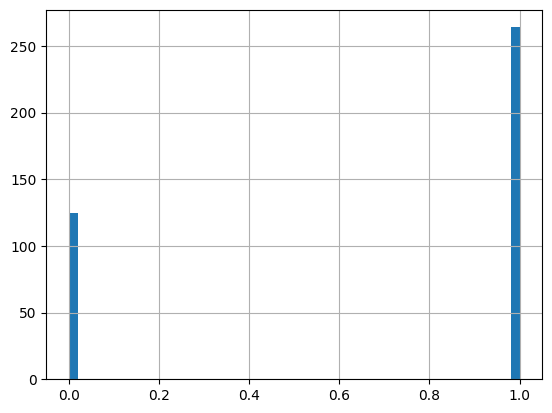

In [ ]:
submission['isAlive'].hist(bins=50)

Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
submission.to_csv("/content/new_submission_1.csv", index=False)